#                       Auto Price Prediction

# PROBLEM STATEMENT:


1.   The goal is to build a predictive model that estimates the price of a cars based on various independent variables like fule-type, engine-type, car      -model_name, body-style, height, width, wheel base, etc.

2.   This will help car manufactures and dealerships understand how different car attributes impact pricing, allowing them to.

           --> optimize car designs[to meet market demand]

           --> adjust business strategies[based on price variations]

           --> predict pricing trends[for new models]

           --> make informed decisions[about production and sales]

# DOMAIN ANALYSIS:
This project come under car price prediction domain focusing on predicting individual price based on the key attributes such as,

1. Symboling: This column represent a risk factor rating assigned to the car by insurance companies.A higher symboling value(3,2,1) means the car is         riskier to drive and insure.A lower or negative symboling value(-2,-1,0) means the cars is safer and more reliable

2. Normalized losses: This column represent the relative average loss payment per insured vehicle. It is a measure of how frequently in an accident and      how expensive the repairs will be.A high value means the can has a higher chance of insurance claims and expensive repairs.A low value means the car     is less likely to need costly repairs and is considered safer.

3. Make: The column represents the brand(manufacture) of the car

4. Fuel Type: The fuel type column represent the type of fuel used by the car's engine either gas or fuel.

5. Aspiration: This column represents the type of air intake system used in the car's engine.

6. Num of doors: This column represent the number of doors a car has two,four.

7. Body style: This column represent the desgin and structure of a car's exterior.

8. Drive wheels: This column represents the dirvetrain system of a car's. Which determines how power is delivered from the engine to the wheels.

9. Engine Location: The column represent where the engine is positioned in the car.

10. Wheel base: The column represent the distance between the front and rear axles of a car.

11. Length: This column represent the length of the car's.

12. Width: This column represent the width of the car's.

13. Height: This column represent the height of the car's.

14. Curb weight: This column represent the total weight of a car without passenger or cargo include car's body,engine and fluids,tires and wheels.

15. Engine type: This column describe the design and value configuration of the car's engine.

16. Number of cylinders: This column represent the number of cylinders in the car's engine.

17. Engine size: This column represent the displacement(capacity) of the engine in cubic centimeters.  It measures the total volume of all the cylinder       in the engine.

18. Fuel system: The column represent the type of fuel delivery system used in the car's engine.

19. Bore: The column represent the diameter of the engine's cylinders measured in inches.

20. Stroke: The column represent the distance the piston travels inside the cylinder during one complete engine cycle.

21. Compression ratio: The column represent the ratio of the total cylinder volume when the piston is at the bottom(BDC) to the volume when the piston       is at the top(TDC).

22. Horsepower: The column represent the engine's power output, measured in HP.

23. Peak rpm: The column represent the maximum revolution per minute at which the engine produces its highest power output.

24. City mpg: The column represent the fuel efficiency of a car when driving in city conditions, measured in miles per gallon(MPG).

25. Highway mpg: The column represent the fuel efficiency of a car when driving on highways, measured in miles per gallon(MPG).

26. Price: The column represent the selling price of a car in US dollar($).

# 1. IMPORTING LIBRARIES

In [6]:
#Importing pandas library for working with datasets
import pandas as pd

#Importing numpy library used to perform mathematical operation and scientific computing.
import numpy as np

#Importing matplotlib library used to create graphs,chart, and other visualization
import matplotlib.pyplot as plt

#Importing seaborn library used to perform making stastical graphics
import seaborn as sns

# Importing OneHotEncoder for encoding
from sklearn.preprocessing import OneHotEncoder

# Importing Label-encoder for encoding
from sklearn.preprocessing import LabelEncoder

# Importing MinMaxScaler for feature scaling
from sklearn.preprocessing import MinMaxScaler

# Importing train_test_split for splitting data into training and testing sets for model evaluation
from sklearn.model_selection import train_test_split

# Importing LinearRegression
from sklearn.linear_model import LinearRegression

# Importing DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

# Importing an ensemble model RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# Importing an advanced boosting model GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Importing an efficient and optimized version of gradient- XGBoost (Regression)
from xgboost import XGBRegressor

# Importing KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor

# Importing RandomizedSearchCV for hyperparameter tuning using randomized search
from sklearn.model_selection import RandomizedSearchCV

# Importing GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Importing Multi-layer Perceptron (MLP) Regressor
from sklearn.neural_network import MLPRegressor

# Importing performance metrics - Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R2_score
from sklearn.metrics import *

#Importing warnings for disable warnings from the code
import warnings
#to ignore the warnings
warnings.filterwarnings('ignore')

#Importing ProfileReport
from ydata_profiling import ProfileReport

# 2. LOADING THE DATA

In [2375]:
data=pd.read_csv('auto_imports.csv')
data

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [2377]:
# Renaming the column names in the dataset
data.rename(columns={'3':'Symboling','?':'Normalized_losses','alfa-romero':'Make','gas':'Fuel_Type','std':
                    'Aspiration','two':'Num_of_Doors','convertible':'Body_Style','rwd':'Drive_Wheels',
                    'front':'Engine_Location','88.60':'Wheel_Base','168.80':'Length','64.10':'Width',
                    '48.80':'Height','2548':'Curb_Weight','dohc':'Engine_Type','four':'Number_of_Cylinders',
                    '130':'Engine_Size','mpfi':'Fuel_System','3.47':'Bore','2.68':'Stroke',
                    '9.00':'Compression_Ratio','111':'Horsepower','5000':'Peak_rpm','21':'City_mpg',
                    '27':'Highway_mpg','13495':'Price'},inplace=True)

In [2379]:
# calling the dataset
data

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


# 3. BASIC CHECKS

In [2381]:
# visualizing the first 10 rows of the data
data.head(10)

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
5,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
6,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
7,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
8,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,176.8,64.8,54.3,2395,ohc,four,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430
9,0,192,bmw,gas,std,four,sedan,rwd,front,101.2,176.8,64.8,54.3,2395,ohc,four,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16925


In [2383]:
# visualizing last 10 row of the data
data.tail(10)

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
190,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,188.8,67.2,57.5,3034,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,13415
191,-2,103,volvo,gas,std,four,sedan,rwd,front,104.3,188.8,67.2,56.2,2935,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,24,28,15985
192,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,188.8,67.2,57.5,3042,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,24,28,16515
193,-2,103,volvo,gas,turbo,four,sedan,rwd,front,104.3,188.8,67.2,56.2,3045,ohc,four,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18420
194,-1,74,volvo,gas,turbo,four,wagon,rwd,front,104.3,188.8,67.2,57.5,3157,ohc,four,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18950
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470
199,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3062,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [14]:
# displaying the full columns along with data
pd.set_option('display.max_columns',None)
data

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [15]:
# extracting column names of the data
data.columns

Index(['Symboling', 'Normalized_losses', 'Make', 'Fuel_Type', 'Aspiration',
       'Num_of_Doors', 'Body_Style', 'Drive_Wheels', 'Engine_Location',
       'Wheel_Base', 'Length', 'Width', 'Height', 'Curb_Weight', 'Engine_Type',
       'Number_of_Cylinders', 'Engine_Size', 'Fuel_System', 'Bore', 'Stroke',
       'Compression_Ratio', 'Horsepower', 'Peak_rpm', 'City_mpg',
       'Highway_mpg', 'Price'],
      dtype='object')

In [16]:
# Checking the index of the data
data.index

RangeIndex(start=0, stop=200, step=1)

In [17]:
# Checking the number of rows and columns of the data
data.shape

(200, 26)

In [18]:
# Checking the basic information of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Symboling            200 non-null    int64  
 1   Normalized_losses    200 non-null    object 
 2   Make                 200 non-null    object 
 3   Fuel_Type            200 non-null    object 
 4   Aspiration           200 non-null    object 
 5   Num_of_Doors         200 non-null    object 
 6   Body_Style           200 non-null    object 
 7   Drive_Wheels         200 non-null    object 
 8   Engine_Location      200 non-null    object 
 9   Wheel_Base           200 non-null    float64
 10  Length               200 non-null    float64
 11  Width                200 non-null    float64
 12  Height               200 non-null    float64
 13  Curb_Weight          200 non-null    int64  
 14  Engine_Type          200 non-null    object 
 15  Number_of_Cylinders  200 non-null    obj

In [19]:
# Checking the statistical information of the numerical column in a data
data.describe()

,Symboling,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Compression_Ratio,City_mpg,Highway_mpg,Price
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.830000,98.848000,174.228000,65.898000,53.791500,2555.705000,126.860000,10.170100,25.200000,30.705000,13205.690000
std,1.248557,6.038261,12.347132,2.102904,2.428449,518.594552,41.650501,4.014163,6.432487,6.827227,7966.982558
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.675000,64.175000,52.000000,2163.000000,97.750000,8.575000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,9.000000,24.000000,30.000000,10270.000000
75%,2.000000,102.400000,183.500000,66.675000,55.525000,2928.250000,142.000000,9.400000,30.000000,34.000000,16500.750000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [20]:
# Checking the statistical information of the categorical column in a data
data.describe(include="O")

,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Engine_Type,Number_of_Cylinders,Fuel_System,Bore,Stroke,Horsepower,Peak_rpm
count,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
unique,52,22,2,2,3,5,3,2,6,7,8,39,37,59,23
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500
freq,36,32,180,164,113,94,118,197,145,156,91,23,19,19,36


In [21]:
# Checking the unique values for all the columns in the data
for i in data:
    print(f"                             {i.title()}                      ")
    print(f"* The number of unique values in {i} column :",data[i].nunique())
    print(">>",data[i].unique())
    print('==================================================================================')

                             Symboling                      
* The number of unique values in Symboling column : 6
>> [ 3  1  2  0 -1 -2]
                             Normalized_Losses                      
* The number of unique values in Normalized_losses column : 52
>> ['?' '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']
                             Make                      
* The number of unique values in Make column : 22
>> ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
                             Fuel_Type                      
* The number of unique values in Fuel

In [22]:
# checking the value counts of all the columns in the data
for i in data:
    print(f"                             {i.title()}                      ")
    print(data[i].value_counts())
    print('==================================================================================')

                             Symboling                      
Symboling
 0    65
 1    52
 2    32
 3    26
-1    22
-2     3
Name: count, dtype: int64
                             Normalized_Losses                      
Normalized_losses
?      36
161    11
91      8
150     7
134     6
128     6
104     6
85      5
94      5
65      5
102     5
74      5
168     5
103     5
95      5
106     4
93      4
118     4
148     4
122     4
83      3
125     3
154     3
115     3
137     3
101     3
119     2
87      2
89      2
192     2
197     2
158     2
81      2
188     2
194     2
153     2
129     2
108     2
110     2
164     2
145     2
113     2
256     1
107     1
90      1
231     1
142     1
121     1
78      1
98      1
186     1
77      1
Name: count, dtype: int64
                             Make                      
Make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
volkswagen       12
subaru           12
peugot         

# 4. HANDLING CORRUPTED VALUES

In [2385]:
# checking corrupted value columns
columns_q = data.columns[(data == '?').any()].tolist()
columns_q

['Normalized_losses',
 'Num_of_Doors',
 'Bore',
 'Stroke',
 'Horsepower',
 'Peak_rpm']

### NORMALIZED LOSSES

In [2387]:
# Finding the number of corrupted values in the column
len(data[data['Normalized_losses']=="?"])

36

In [2389]:
# replace the corrputed value '?' to median of the column
data['Normalized_losses'] = data['Normalized_losses'].replace('?', pd.to_numeric(data['Normalized_losses'], errors='coerce').median())

In [2391]:
# change the column values object to int
data['Normalized_losses']=data['Normalized_losses'].astype(int)

In [2393]:
# Verifying
len(data[data['Normalized_losses']=="?"])

0

### BORE

In [2395]:
# Finding the number of corrupted values in the column
len(data[data['Bore']=="?"])

4

In [2397]:
#replace the value '?' to median of the column
data['Bore'] = data['Bore'].replace('?', pd.to_numeric(data['Bore'], errors='coerce').median())

In [2399]:
#change the column values object to float
data['Bore']=data['Bore'].astype(float)

In [2401]:
# Verifying
len(data[data['Bore']=="?"])

0

### STROKE

In [2403]:
# Finding the number of corrupted values in the column
len(data[data['Stroke']=="?"])

4

In [2405]:
#replace the corrputed value '?' to median of the column
data['Stroke'] = data['Stroke'].replace('?', pd.to_numeric(data['Stroke'], errors='coerce').median())

In [2407]:
#change the column corrputed values object to float
data['Stroke']=data['Stroke'].astype(float)

In [2409]:
# Verifying
len(data[data['Normalized_losses']=="?"])

0

### HORSEPOWER

In [2411]:
# Finding the number of corrupted values in the column
len(data[data['Horsepower']=="?"])

2

In [2413]:
#replace the corrputed value '?' to median of the column
data['Horsepower'] = data['Horsepower'].replace('?', pd.to_numeric(data['Horsepower'], errors='coerce').median())

In [2415]:
#change the column corrputed values object to int
data['Horsepower']=data['Horsepower'].astype(int)

In [2417]:
# Verifying
len(data[data['Normalized_losses']=="?"])

0

### PEAK RPM

In [2419]:
# Finding the number of corrupted values in the column
len(data[data['Peak_rpm']=="?"])

2

In [2421]:
#replace the corrputed value '?' to median of the column
data['Peak_rpm'] = data['Peak_rpm'].replace('?', pd.to_numeric(data['Peak_rpm'], errors='coerce').median())

In [2423]:
#change the column corrputed values object to int
data['Peak_rpm']=data['Peak_rpm'].astype(int)

In [2425]:
# Verifying
len(data[data['Peak_rpm']=="?"])

0

### NUMBER OF DOORS

In [2427]:
# Finding the number of corrupted values in the column
len(data[data['Num_of_Doors']=="?"])

2

In [2429]:
#replace the corrputed value '?' to mode of the column
data['Num_of_Doors'].replace('?',data['Num_of_Doors'].mode()[0],inplace=True)

In [2431]:
# Finding the number of corrupted values in the column
len(data[data['Num_of_Doors']=="?"])

0

In [2433]:
#check the value counts of the column
data['Num_of_Doors'].value_counts()

Num_of_Doors
four    115
two      85
Name: count, dtype: int64

# INSIGHTS

1. The dataset has 200 rows and 26 columns, with 16 numerical columns and 10 categorical columns.

2. The dataset contains corrupted values represented by '?'. These corrupted values are found in the columns such as Normalized_losses, Bore, Stroke, Horsepower, Peak_rpm and Num_of_Doors.

# 5. EXPLORATORY DATA ANALYSIS (EDA)

## 5.1. PROFILE REPORT

In [ ]:
report=ProfileReport(data,title="Profile Report")
report

Full interactive profiling report saved separately as reports/EDA_Profile_Report.html (too large to embed inline).


## 5.2. UNIVARIATE ANALYSIS FOR NUMERICAL COLUMNS

In [60]:
# Numerical columns of the data
numerical_col = data.select_dtypes(include=["int","float"]).columns
numerical_col

Index(['Symboling', 'Normalized_losses', 'Wheel_Base', 'Length', 'Width',
       'Height', 'Curb_Weight', 'Engine_Size', 'Bore', 'Stroke',
       'Compression_Ratio', 'Horsepower', 'Peak_rpm', 'City_mpg',
       'Highway_mpg', 'Price'],
      dtype='object')

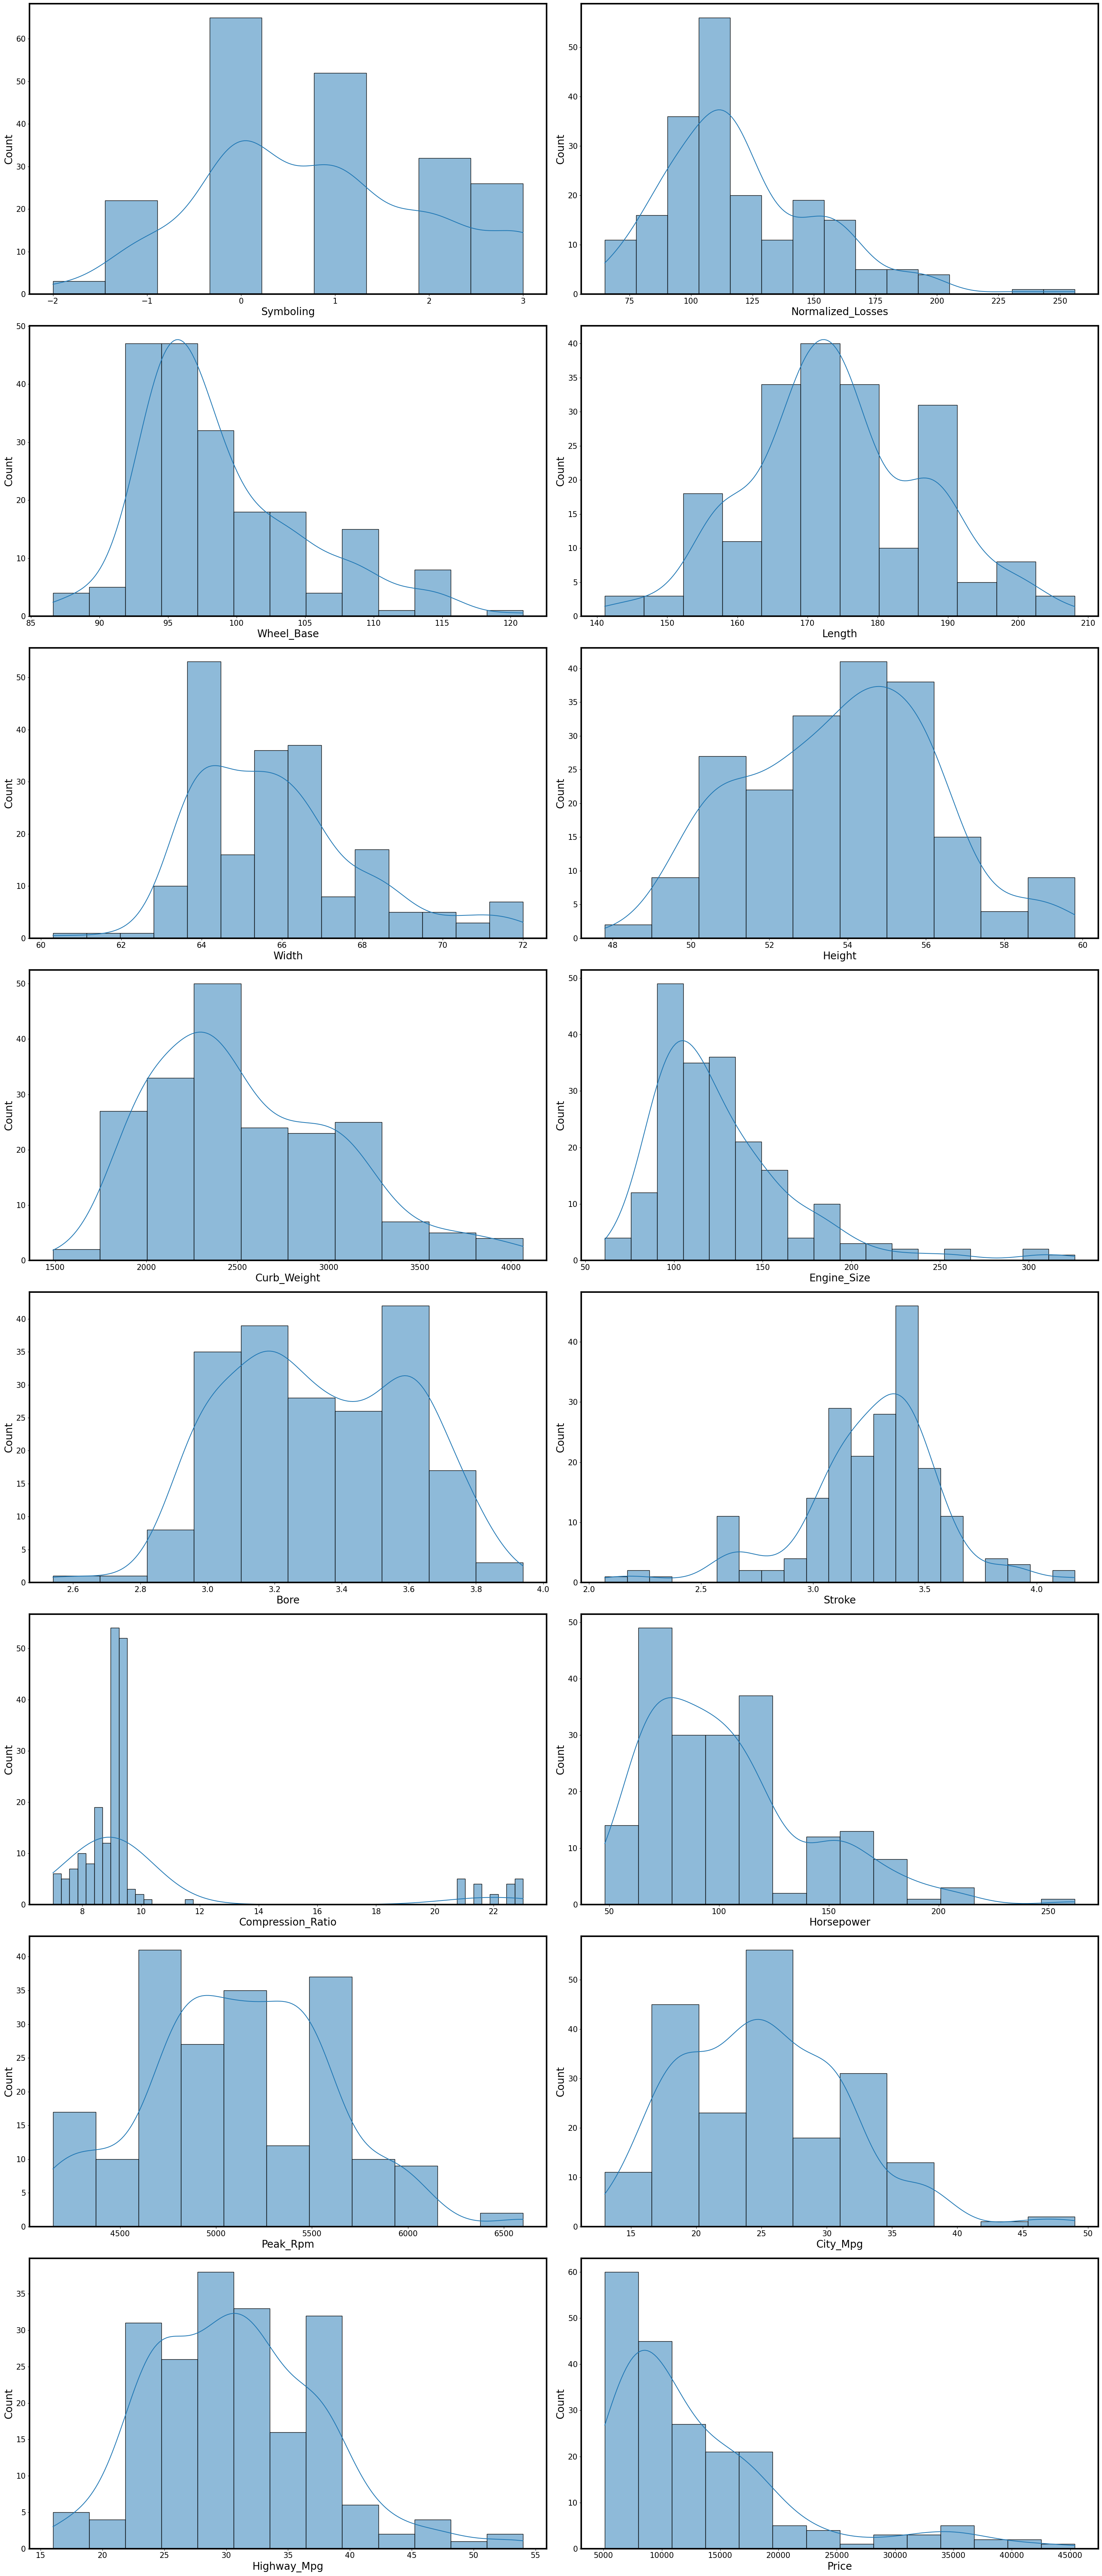

In [61]:
plt.figure(figsize=(30,70),facecolor="white")
pltnum =1

for i in numerical_col:
    if pltnum <=16:
        sp = plt.subplot(8,2,pltnum)
        sns.histplot(data[i],kde=True)
        plt.xlabel(i.title(),fontsize=20)
        plt.ylabel("Count",fontsize=20)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        sp.spines['top'].set_linewidth(3)
        sp.spines['bottom'].set_linewidth(3)
        sp.spines['left'].set_linewidth(3)
        sp.spines['right'].set_linewidth(3)
    pltnum +=1
plt.tight_layout()
plt.show()

## 5.3. UNIVARIATE ANALYSIS FOR CATEGORICAL COLUMNS

In [63]:
# Categorical columns of the data
category_col = data.select_dtypes(include=["object"]).columns
category_col

Index(['Make', 'Fuel_Type', 'Aspiration', 'Num_of_Doors', 'Body_Style',
       'Drive_Wheels', 'Engine_Location', 'Engine_Type', 'Number_of_Cylinders',
       'Fuel_System'],
      dtype='object')

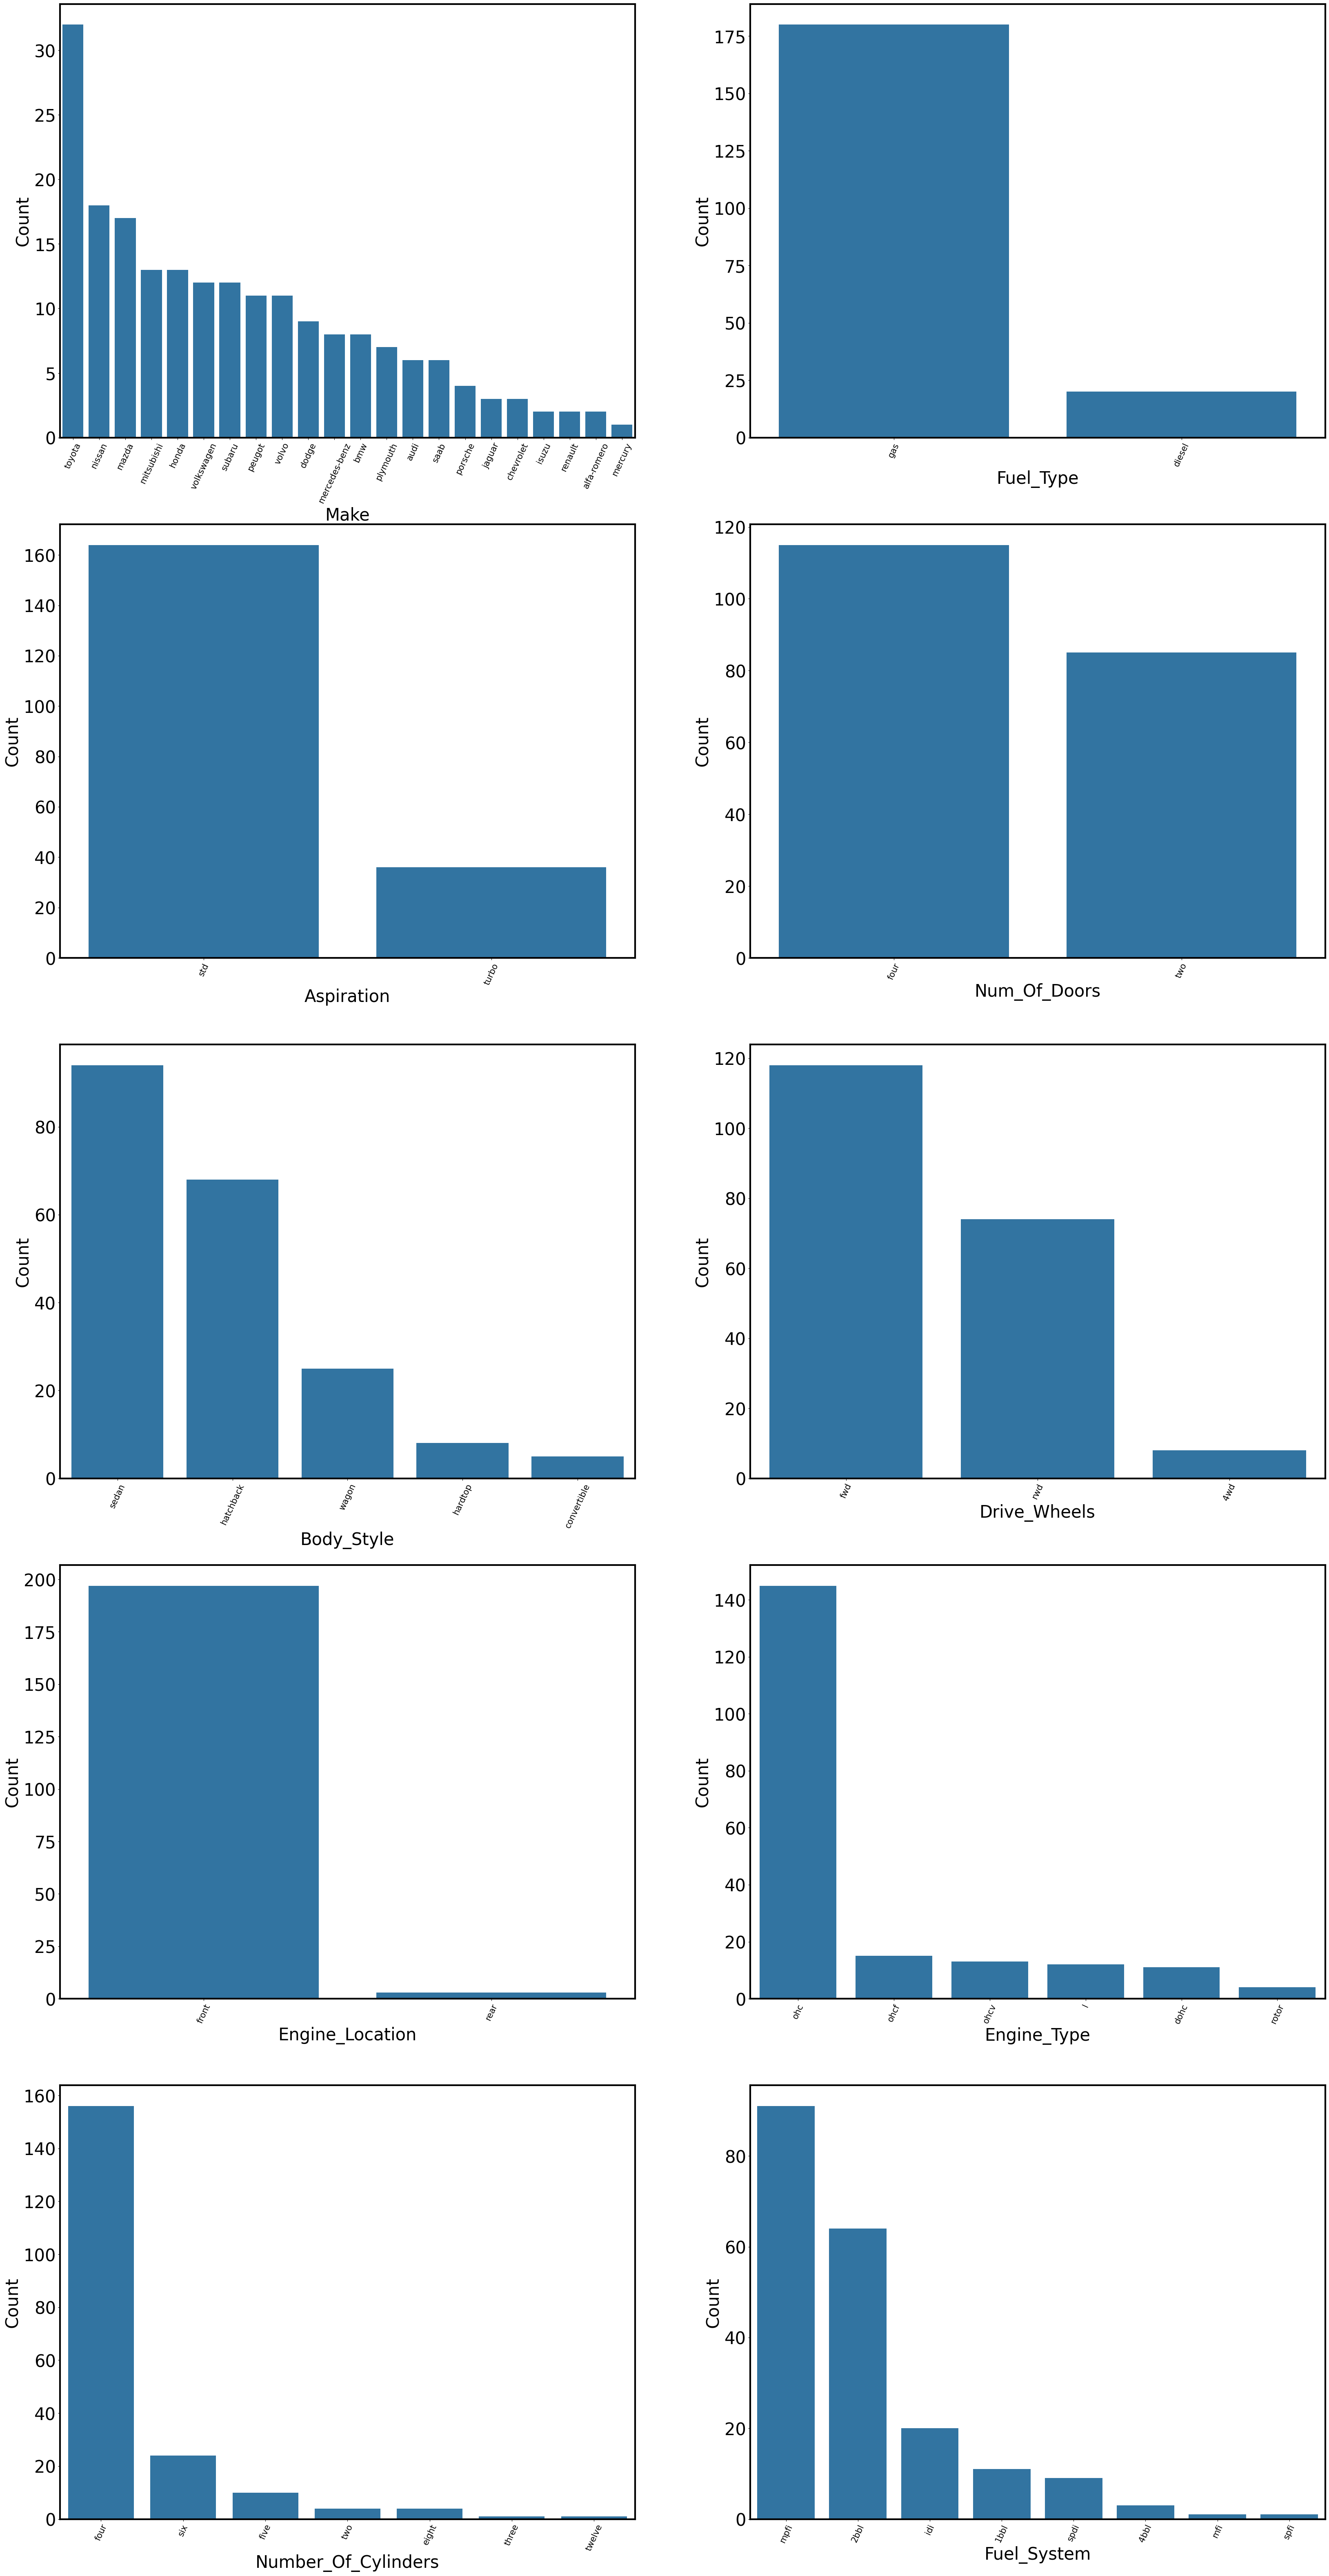

In [64]:

plt.figure(figsize=(40,80),facecolor="white")
plttnum=1
for i in category_col:
    if plttnum <= 10:
        sp = plt.subplot(5, 2, plttnum)

        # Create a bar plot with category counts
        sns.barplot(x=data[i].value_counts().index, y=data[i].value_counts().values)

        # Set labels and title
        plt.xlabel(i.title(), fontsize=30)
        plt.ylabel("Count", fontsize=30)
        plt.xticks(rotation=65, fontsize=15)  # Rotate x-axis labels if needed
        plt.yticks(fontsize=30)  # Adjust y-axis font size
        sp.spines['top'].set_linewidth(3)
        sp.spines['bottom'].set_linewidth(3)
        sp.spines['left'].set_linewidth(3)
        sp.spines['right'].set_linewidth(3)

    plttnum += 1  # Increment plot number

  # Adjust subplots to avoid overlap
plt.show()


## 5.4. BIVARIATE ANALYSIS

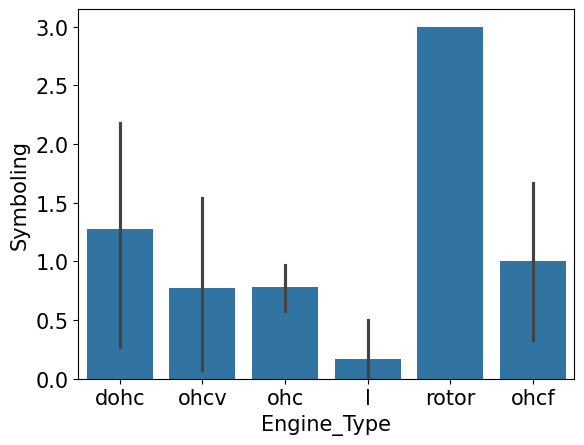

In [66]:
# Engine_Type vs Symboling
sns.barplot(data,x="Engine_Type",y="Symboling")
plt.xlabel("Engine_Type",fontsize=15)
plt.ylabel("Symboling",fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

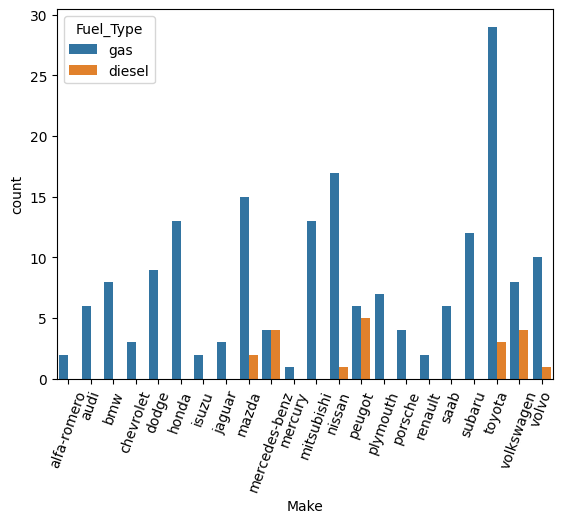

In [67]:
# Make vs Fuel_Type
sns.countplot(x='Make',hue='Fuel_Type',data=data)
plt.xticks(rotation=70,fontsize=10)
plt.show()

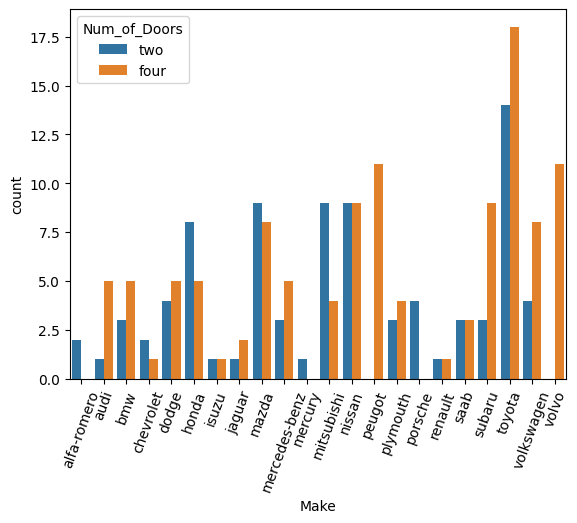

In [68]:
# Make vs Num_of_Doors
sns.countplot(x='Make',hue='Num_of_Doors',data=data)
plt.xticks(rotation=70,fontsize=10)
plt.show()

In [69]:
#Make vs Horsepower
plt.figure(figsize=(100,80))
sns.barplot(data,x="Make",y="Horsepower")
plt.xlabel("Make",fontsize=70)
plt.ylabel("Horsepower",fontsize=70)
plt.xticks(rotation=45,fontsize=50)
plt.yticks(fontsize=50)
plt.show()

In [70]:
# checking the maximum value of 'Horsepower'
data['Horsepower'].max()

262

In [71]:
# Body_style vs Price
plt.figure(figsize=(100,80))
sns.barplot(data,x="Body_Style",y="Price")
plt.xlabel("Body_Style",fontsize=70)
plt.ylabel("Price",fontsize=70)
plt.xticks(rotation=45,fontsize=50)
plt.yticks(fontsize=50)
plt.show()

In [72]:
# Fuel_Type vs City_mpg
plt.figure(figsize=(100,80))
sns.barplot(data,x="Fuel_Type",y="City_mpg")
plt.xlabel("Fuel_Type",fontsize=70)
plt.ylabel("City_mpg",fontsize=70)
plt.xticks(rotation=45,fontsize=50)
plt.yticks(fontsize=50)
plt.show()

## 5.5. MULTIVARIATE ANALYSIS

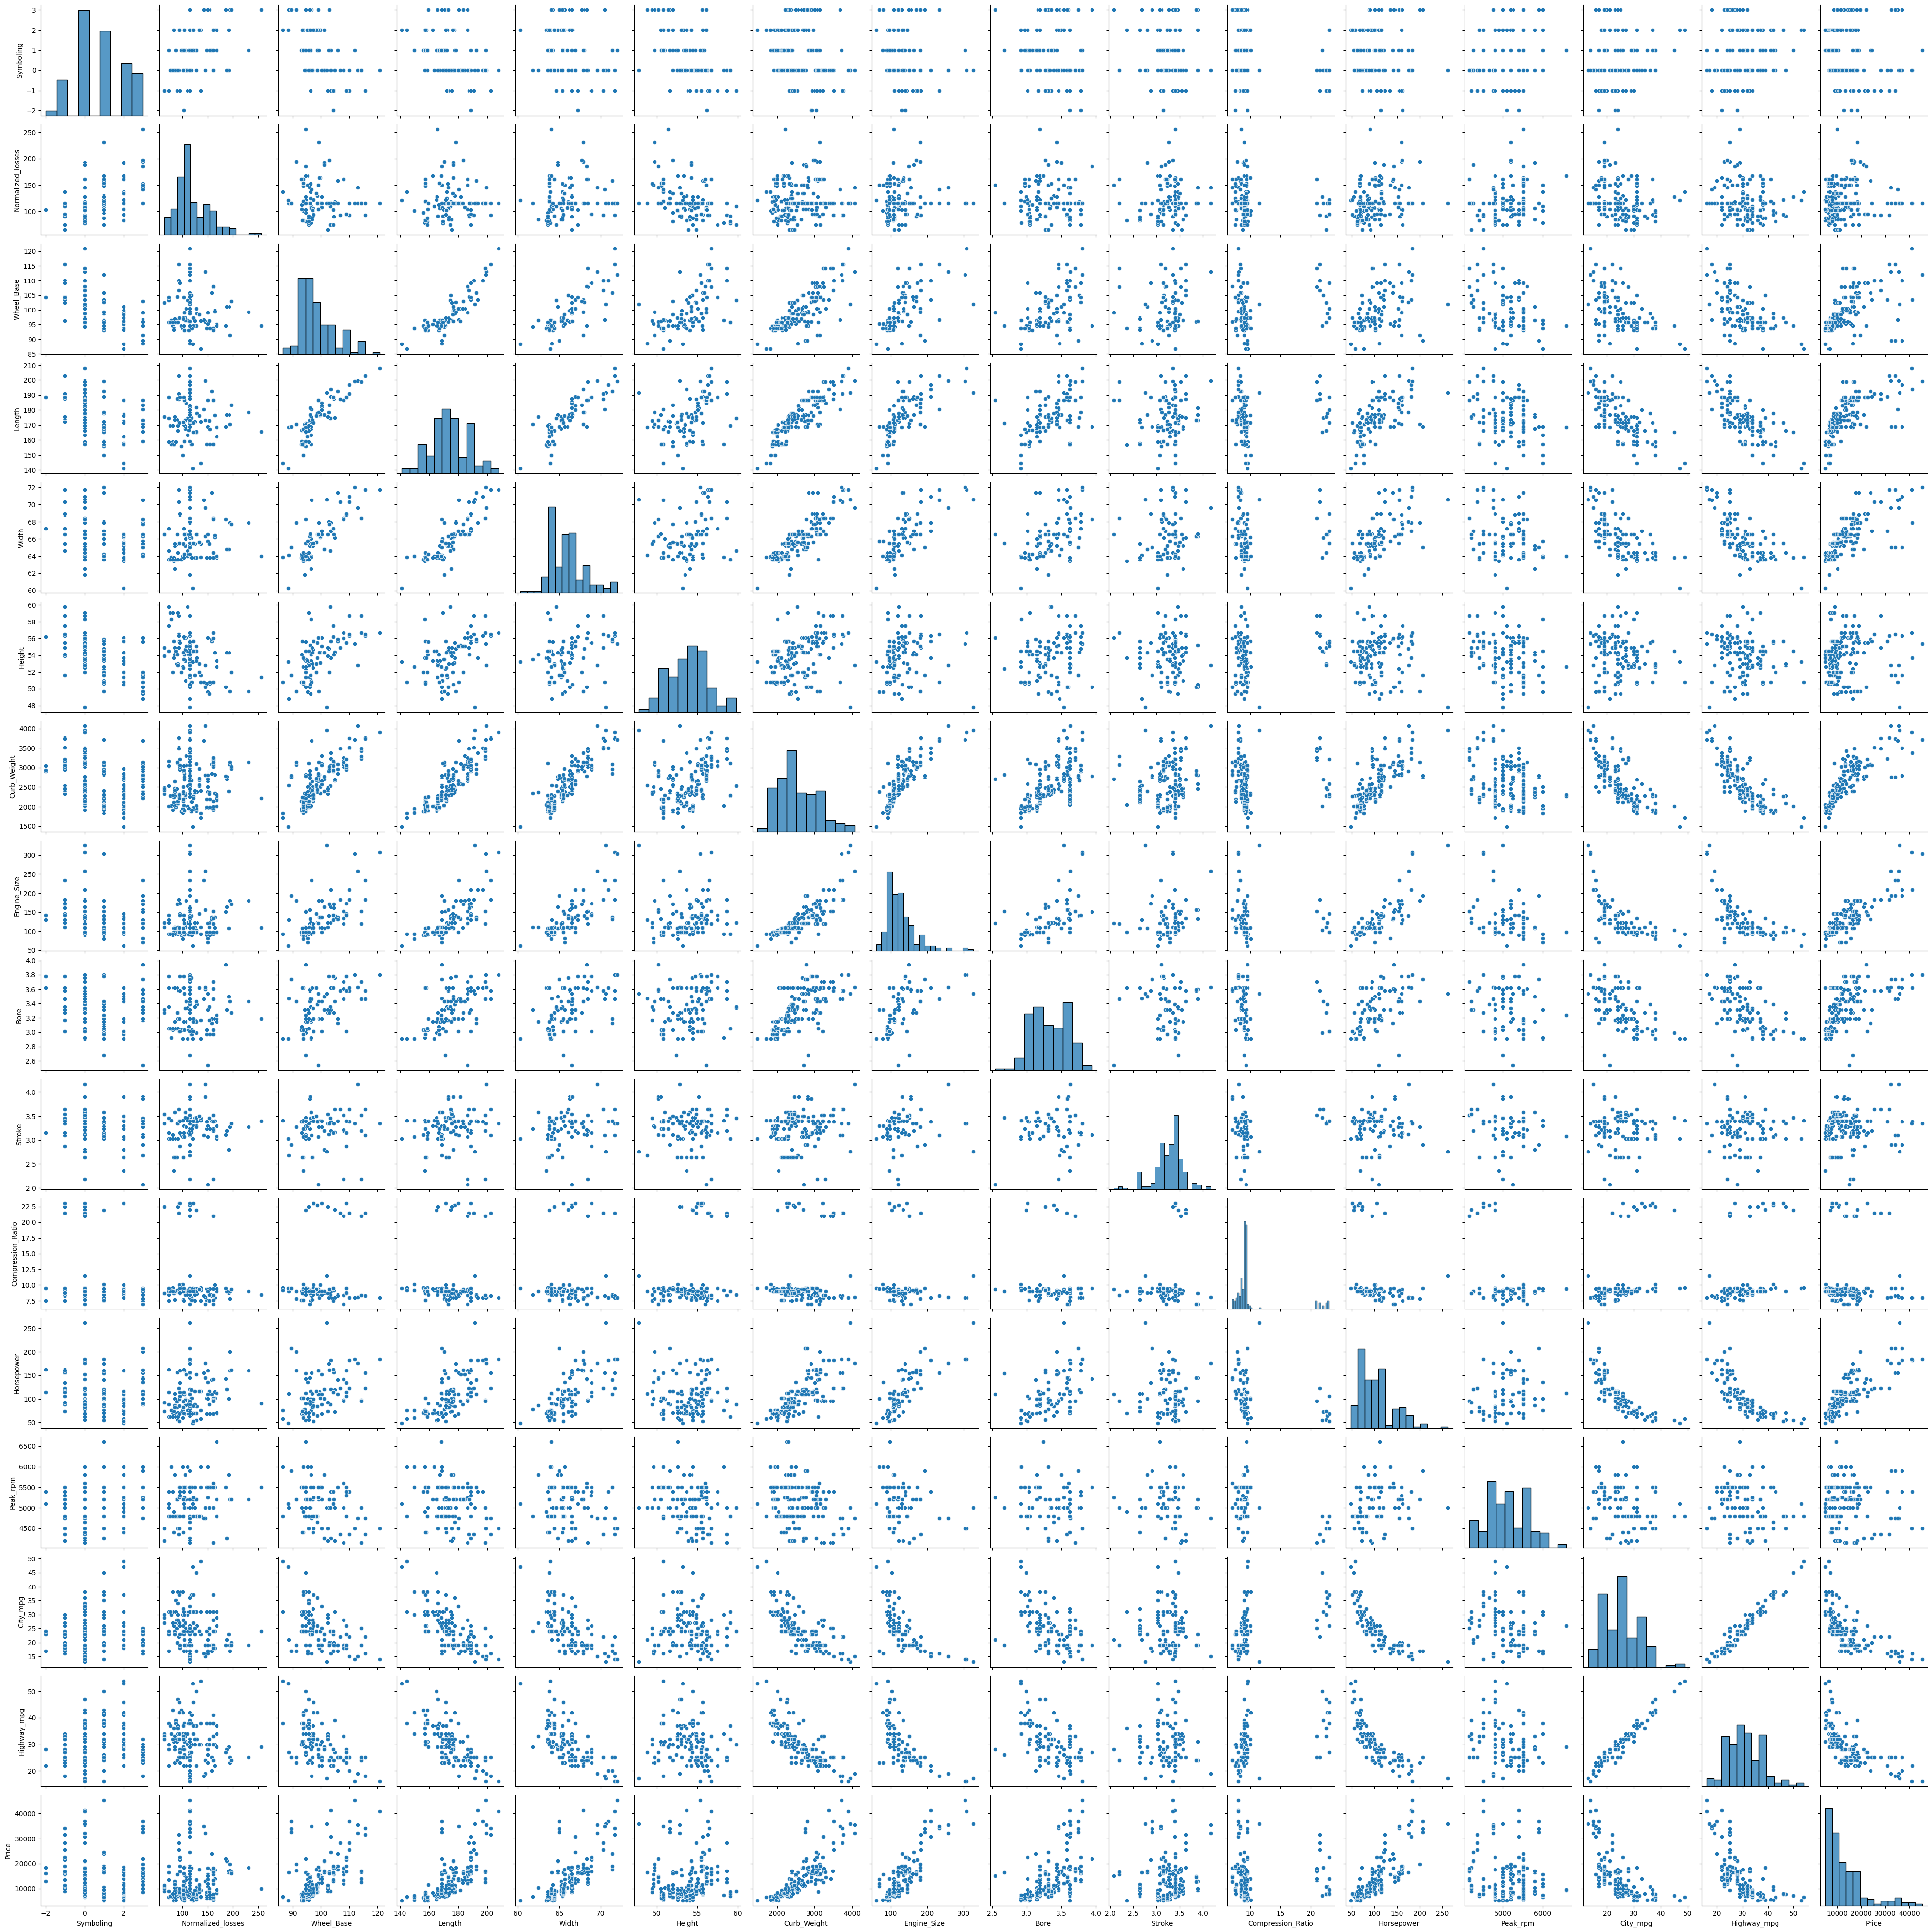

In [74]:
sns.pairplot(data)
plt.show()

# INSIGHT FROM EDA:

1. The rotor engine_type has higher risk factor(3) compare with other engine_types.
2. Among all manufacturers, Toyota produces the highest number of gas-fueled cars.
3. Toyota stands out as the leading producer of cars with both two-door and four-door configurations, surpassing other manufacturers .
4. Jaguar leads in horsepower among car manufacturers, producing the most powerful vehicle with 262 HP.
5. When compared to other body styles, convertible cars stand out as the most expensive, having the highest price among all vehicle types.